In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from scipy.stats import ks_2samp
import pandas as pd
import os
import sys

In [2]:
ball_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv\ballbyball.csv')
country_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/country.csv')
ground_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/ground.csv')
matches_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/matches.csv')
players_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/players.csv')
season_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/season.csv')
team_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/team.csv')
town_df = pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\csv/town.csv')

In [3]:
ball_df.head()

,Unnamed: 0,match_id,match_obj_id,inningNumber,overNumber,ballNumber,oversUnique,oversActual,batsmanPlayerId,bowlerPlayerId,...,legbyes,wides,noballs,penalties,run,batsmanRuns,totalRuns,totalWickets,outPlayerId,shotType
0,0,100706,1273712,1,1,1,0.01,0.1,52584,87127,...,0,0,0,0,0,0,0,0,NaN,DEFENDED
1,1,100706,1273712,1,1,2,0.02,0.2,52584,87127,...,0,0,0,0,0,0,0,0,NaN,CUT_SHOT
2,2,100706,1273712,1,1,3,0.03,0.3,52584,87127,...,0,0,0,0,0,0,0,0,NaN,DEFENDED
3,3,100706,1273712,1,1,4,0.04,0.4,52584,87127,...,0,0,0,0,0,0,0,0,NaN,FLICK
4,4,100706,1273712,1,1,5,0.05,0.5,52584,87127,...,0,0,0,0,0,0,0,1,52584.0,COVER_DRIVE


In [4]:
ball_df['totalRuns'] = ball_df['totalRuns'] - ball_df['run']
ball_df['totalWickets'] = ball_df['totalWickets'] - ball_df['isWicket'].apply(lambda x: 1 if x else 0)

In [5]:
country_df.head()

,Country ID,Country Name,Country Abbreviation
0,1,England,ENG
1,4,West Indies,WI
2,8,Sri Lanka,SL
3,25,Bangladesh,BAN
4,6,India,IND


In [6]:
ground_df.head()

,Ground ID,Ground Name,Ground Slug,Town ID,Capacity
0,10,"Lord's, London",lord-s-london,224,30000
1,45,"Kennington Oval, London",kennington-oval-london,224,23500
2,34,"Trent Bridge, Nottingham",trent-bridge-nottingham,254,"15,350 (to be 17,000)"
3,1986,"Providence Stadium, Guyana",providence-stadium-guyana,1076,"15,000"
4,1697,"Beausejour Stadium, Gros Islet, St Lucia",daren-sammy-national-cricket-stadium-gros-isle...,1019,"12,400"


In [7]:
matches_df.head()

,season_id,match_id,slug,title,time_of_day,date,time,status,status_description,winner_team_id,toss_winner_team_id,toss_choice,ground_id,team_1_id,team_2_id,team_1_score,team_1_scoreInfo,team_2_scoreInfo
0,4162,18581,england-vs-netherlands-1st-match-group-b,"1st Match, Group B",daynight,2009-06-05,22:00:00,RESULT,Netherlands won by 4 wickets (with 0 balls rem...,15.0,15.0,2.0,10,1,15,163/6,NaN,"20 ov, T:163"
1,4162,18582,new-zealand-vs-scotland-2nd-match-group-d,"2nd Match, Group D",day,2009-06-06,14:30:00,RESULT,New Zealand won by 7 wickets (with 6 balls rem...,5.0,5.0,2.0,45,30,5,90/3,7/7 ov,"6/7 ov, T:90"
2,4162,18583,australia-vs-west-indies-3rd-match-group-c,"3rd Match, Group C",day,2009-06-06,18:30:00,RESULT,West Indies won by 7 wickets (with 25 balls re...,4.0,2.0,1.0,45,2,4,172/3,NaN,"15.5/20 ov, T:170"
3,4162,18584,bangladesh-vs-india-4th-match-group-a,"4th Match, Group A",night,2009-06-06,22:30:00,RESULT,India won by 25 runs,6.0,6.0,1.0,34,6,25,155/8,NaN,"20 ov, T:181"
4,4162,18585,scotland-vs-south-africa-5th-match-group-d,"5th Match, Group D",day,2009-06-07,18:00:00,RESULT,South Africa won by 130 runs,3.0,30.0,2.0,45,3,30,81,NaN,"15.4/20 ov, T:212"


In [8]:
players_df.head()

,ID,Name,Role,Full Name,Image,DOB,Batting Style (s),Bowling Style (s),Batting Style (l),Bowling Style(l),Team ID,Playing Role
0,2230,RT Ponting,C,Ricky Ponting,"https://img1.hscicdn.com/image/upload/f_auto,t...",19-12-1974,rhb,rm,right-hand bat,right-arm medium,2.0,top-order batter
1,8876,MJ Clarke,VC,Michael Clarke,"https://img1.hscicdn.com/image/upload/f_auto,t...",2-4-1981,rhb,sla,right-hand bat,slow left-arm orthodox,2.0,middle-order batter
2,7445,NW Bracken,P,Nathan Bracken,"https://img1.hscicdn.com/image/upload/f_auto,t...",12-9-1977,rhb,lfm,right-hand bat,left-arm fast-medium,2.0,bowler
3,6426,BJ Haddin,WK,Brad Haddin,"https://img1.hscicdn.com/image/upload/f_auto,t...",23-10-1977,rhb,NaN,right-hand bat,NaN,2.0,wicketkeeper batter
4,10122,NM Hauritz,P,Nathan Hauritz,"https://img1.hscicdn.com/image/upload/f_auto,t...",18-10-1981,rhb,ob,right-hand bat,right-arm offbreak,2.0,bowler


In [9]:
season_df.head()

,season_id,name,year,description,season,startDate,endDate,totalSquads
0,4162,ICC World Twenty20,2009,in England,2009,2009-06-05T00:00:00.000Z,2009-06-21T00:00:00.000Z,12
1,5195,ICC World Twenty20,2010,in West Indies,2010,2010-04-30T00:00:00.000Z,2010-05-16T00:00:00.000Z,12
2,6856,ICC World Twenty20,2012/13,in Sri Lanka,2012/13,2012-09-18T00:00:00.000Z,2012-10-07T00:00:00.000Z,12
3,8083,World T20,2013/14,in Bangladesh,2013/14,2014-03-16T00:00:00.000Z,2014-04-06T00:00:00.000Z,16
4,10291,World T20,2015/16,in India,2015/16,2016-03-08T00:00:00.000Z,2016-04-03T00:00:00.000Z,16


In [10]:
team_df.head()

,Team ID,Team Name,Team Abbreviation,Image URL,Country ID
0,1,England,ENG,/db/PICTURES/CMS/313100/313114.logo.png,1
1,15,Netherlands,NED,/db/PICTURES/CMS/313100/313136.logo.png,15
2,30,Scotland,SCOT,/db/PICTURES/CMS/313100/313150.logo.png,30
3,5,New Zealand,NZ,/db/PICTURES/CMS/340500/340505.png,5
4,2,Australia,AUS,/db/PICTURES/CMS/340400/340493.png,2


In [11]:
town_df.head()

,Town ID,Town Name,Country ID
0,224,London,1
1,254,Nottingham,1
2,1076,Providence,4
3,1019,Gros Islet,4
4,988,Bridgetown,4


In [12]:
ground_df.drop(['Ground Slug', 'Town ID', 'Capacity'], axis=1, inplace=True)

In [13]:
matches_df.rename(columns={'ground_id': 'Ground ID'}, inplace=True)

matches_df = pd.merge(matches_df, ground_df, on='Ground ID', how='inner')

In [14]:
matches_df.head()

,season_id,match_id,slug,title,time_of_day,date,time,status,status_description,winner_team_id,toss_winner_team_id,toss_choice,Ground ID,team_1_id,team_2_id,team_1_score,team_1_scoreInfo,team_2_scoreInfo,Ground Name
0,4162,18581,england-vs-netherlands-1st-match-group-b,"1st Match, Group B",daynight,2009-06-05,22:00:00,RESULT,Netherlands won by 4 wickets (with 0 balls rem...,15.0,15.0,2.0,10,1,15,163/6,NaN,"20 ov, T:163","Lord's, London"
1,4162,18582,new-zealand-vs-scotland-2nd-match-group-d,"2nd Match, Group D",day,2009-06-06,14:30:00,RESULT,New Zealand won by 7 wickets (with 6 balls rem...,5.0,5.0,2.0,45,30,5,90/3,7/7 ov,"6/7 ov, T:90","Kennington Oval, London"
2,4162,18583,australia-vs-west-indies-3rd-match-group-c,"3rd Match, Group C",day,2009-06-06,18:30:00,RESULT,West Indies won by 7 wickets (with 25 balls re...,4.0,2.0,1.0,45,2,4,172/3,NaN,"15.5/20 ov, T:170","Kennington Oval, London"
3,4162,18584,bangladesh-vs-india-4th-match-group-a,"4th Match, Group A",night,2009-06-06,22:30:00,RESULT,India won by 25 runs,6.0,6.0,1.0,34,6,25,155/8,NaN,"20 ov, T:181","Trent Bridge, Nottingham"
4,4162,18585,scotland-vs-south-africa-5th-match-group-d,"5th Match, Group D",day,2009-06-07,18:00:00,RESULT,South Africa won by 130 runs,3.0,30.0,2.0,45,3,30,81,NaN,"15.4/20 ov, T:212","Kennington Oval, London"


In [15]:
matches_df.drop(['season_id', 'slug', 'title', 'date', 'time', 'status', 'status_description', 'winner_team_id', 'toss_winner_team_id', 'toss_choice', 'Ground ID', 'team_1_id', 'team_2_id', 'team_1_score', 'team_1_scoreInfo', 'team_2_scoreInfo'], axis=1, inplace=True)

In [16]:
matches_df.head()

,match_id,time_of_day,Ground Name
0,18581,daynight,"Lord's, London"
1,18582,day,"Kennington Oval, London"
2,18583,day,"Kennington Oval, London"
3,18584,night,"Trent Bridge, Nottingham"
4,18585,day,"Kennington Oval, London"


In [17]:
players_df.drop([ 'Image', 'DOB', 'Team ID'], axis=1, inplace=True)

players_df.head()

,ID,Name,Role,Full Name,Batting Style (s),Bowling Style (s),Batting Style (l),Bowling Style(l),Playing Role
0,2230,RT Ponting,C,Ricky Ponting,rhb,rm,right-hand bat,right-arm medium,top-order batter
1,8876,MJ Clarke,VC,Michael Clarke,rhb,sla,right-hand bat,slow left-arm orthodox,middle-order batter
2,7445,NW Bracken,P,Nathan Bracken,rhb,lfm,right-hand bat,left-arm fast-medium,bowler
3,6426,BJ Haddin,WK,Brad Haddin,rhb,NaN,right-hand bat,NaN,wicketkeeper batter
4,10122,NM Hauritz,P,Nathan Hauritz,rhb,ob,right-hand bat,right-arm offbreak,bowler


In [18]:
ball_df = pd.merge(ball_df, matches_df, on='match_id', how='inner')

ball_df.head()

,Unnamed: 0,match_id,match_obj_id,inningNumber,overNumber,ballNumber,oversUnique,oversActual,batsmanPlayerId,bowlerPlayerId,...,noballs,penalties,run,batsmanRuns,totalRuns,totalWickets,outPlayerId,shotType,time_of_day,Ground Name
0,0,100706,1273712,1,1,1,0.01,0.1,52584,87127,...,0,0,0,0,0,0,NaN,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
1,1,100706,1273712,1,1,2,0.02,0.2,52584,87127,...,0,0,0,0,0,0,NaN,CUT_SHOT,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
2,2,100706,1273712,1,1,3,0.03,0.3,52584,87127,...,0,0,0,0,0,0,NaN,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
3,3,100706,1273712,1,1,4,0.04,0.4,52584,87127,...,0,0,0,0,0,0,NaN,FLICK,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
4,4,100706,1273712,1,1,5,0.05,0.5,52584,87127,...,0,0,0,0,0,0,52584.0,COVER_DRIVE,day,Al Amerat Cricket Ground Oman Cricket (Ministr...


In [21]:
ball_df.drop([ 'overNumber', 'ballNumber', 'oversUnique', 'penalties', 'batsmanRuns', 'outPlayerId'], axis=1, inplace=True)
ball_df.reset_index(inplace=True)
ball_df.head()

,index,Unnamed: 0,match_id,match_obj_id,inningNumber,oversActual,batsmanPlayerId,bowlerPlayerId,pitchLine,pitchLength,...,byes,legbyes,wides,noballs,run,totalRuns,totalWickets,shotType,time_of_day,Ground Name
0,0,0,100706,1273712,1,0.1,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
1,1,1,100706,1273712,1,0.2,52584,87127,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,...,0,0,0,0,0,0,0,CUT_SHOT,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
2,2,2,100706,1273712,1,0.3,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
3,3,3,100706,1273712,1,0.4,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,...,0,0,0,0,0,0,0,FLICK,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
4,4,4,100706,1273712,1,0.5,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,...,0,0,0,0,0,0,0,COVER_DRIVE,day,Al Amerat Cricket Ground Oman Cricket (Ministr...


In [25]:
ball_df.drop(['index'],inplace=True,axis=1)

In [26]:
ball_df.head()

,Unnamed: 0,match_id,match_obj_id,inningNumber,oversActual,batsmanPlayerId,bowlerPlayerId,pitchLine,pitchLength,isFour,...,byes,legbyes,wides,noballs,run,totalRuns,totalWickets,shotType,time_of_day,Ground Name
0,0,100706,1273712,1,0.1,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
1,1,100706,1273712,1,0.2,52584,87127,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,...,0,0,0,0,0,0,0,CUT_SHOT,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
2,2,100706,1273712,1,0.3,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
3,3,100706,1273712,1,0.4,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,FLICK,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
4,4,100706,1273712,1,0.5,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,COVER_DRIVE,day,Al Amerat Cricket Ground Oman Cricket (Ministr...


In [27]:
ball_df.reset_index(drop=True)

,Unnamed: 0,match_id,match_obj_id,inningNumber,oversActual,batsmanPlayerId,bowlerPlayerId,pitchLine,pitchLength,isFour,...,byes,legbyes,wides,noballs,run,totalRuns,totalWickets,shotType,time_of_day,Ground Name
0,0,100706,1273712,1,0.1,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
1,1,100706,1273712,1,0.2,52584,87127,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,...,0,0,0,0,0,0,0,CUT_SHOT,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
2,2,100706,1273712,1,0.3,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
3,3,100706,1273712,1,0.4,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,FLICK,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
4,4,100706,1273712,1,0.5,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,...,0,0,0,0,0,0,0,COVER_DRIVE,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60321,60321,74999,951373,2,8.3,10238,45443,OUTSIDE_OFFSTUMP,GOOD_LENGTH,False,...,0,0,0,0,1,47,3,COVER_DRIVE,night,"Eden Gardens, Kolkata"
60322,60322,74999,951373,2,8.4,45257,45443,DOWN_LEG,SHORT_OF_A_GOOD_LENGTH,False,...,0,0,1,0,1,48,3,LEFT_ALONE,night,"Eden Gardens, Kolkata"
60323,60323,74999,951373,2,8.4,45257,45443,OUTSIDE_OFFSTUMP,SHORT_OF_A_GOOD_LENGTH,False,...,0,0,0,0,0,49,3,DEFENDED,night,"Eden Gardens, Kolkata"
60324,60324,74999,951373,2,8.5,45257,45443,OUTSIDE_OFFSTUMP,GOOD_LENGTH,False,...,0,0,0,0,1,49,3,DEFENDED,night,"Eden Gardens, Kolkata"


In [28]:
ball_df.columns

Index(['Unnamed: 0', 'match_id', 'match_obj_id', 'inningNumber', 'oversActual',
       'batsmanPlayerId', 'bowlerPlayerId', 'pitchLine', 'pitchLength',
       'isFour', 'isSix', 'isWicket', 'byes', 'legbyes', 'wides', 'noballs',
       'run', 'totalRuns', 'totalWickets', 'shotType', 'time_of_day',
       'Ground Name'],
      dtype='object')

In [30]:
ball_df=ball_df[['match_id', 'match_obj_id', 'inningNumber', 'oversActual',
       'batsmanPlayerId', 'bowlerPlayerId', 'pitchLine', 'pitchLength',
       'isFour', 'isSix', 'isWicket', 'byes', 'legbyes', 'wides', 'noballs',
       'run', 'totalRuns', 'totalWickets', 'shotType', 'time_of_day',
       'Ground Name']]

In [31]:
ball_df.head()

,match_id,match_obj_id,inningNumber,oversActual,batsmanPlayerId,bowlerPlayerId,pitchLine,pitchLength,isFour,isSix,...,byes,legbyes,wides,noballs,run,totalRuns,totalWickets,shotType,time_of_day,Ground Name
0,100706,1273712,1,0.1,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
1,100706,1273712,1,0.2,52584,87127,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,False,...,0,0,0,0,0,0,0,CUT_SHOT,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
2,100706,1273712,1,0.3,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,0,0,0,0,0,0,0,DEFENDED,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
3,100706,1273712,1,0.4,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,0,0,0,0,0,0,0,FLICK,day,Al Amerat Cricket Ground Oman Cricket (Ministr...
4,100706,1273712,1,0.5,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,0,0,0,0,0,0,0,COVER_DRIVE,day,Al Amerat Cricket Ground Oman Cricket (Ministr...


In [32]:
ball_df = ball_df.merge(players_df, how='left', left_on='batsmanPlayerId', right_on='ID', suffixes=('', '_batsman'))

ball_df.rename(columns={
    'Name': 'Batsman_Name',
    'Role': 'Batsman_Role',
    'Batting Style (l)': 'Batsman_Batting_Style',
    'Bowling Style(l)': 'Batsman_Bowling_Style',
    'Playing Role': 'Batsman_Playing_Role'
}, inplace=True)

ball_df.drop(columns=['ID'], inplace=True)

ball_df = ball_df.merge(players_df, how='left', left_on='bowlerPlayerId', right_on='ID', suffixes=('', '_bowler'))

ball_df.rename(columns={
    'Name': 'Bowler_Name',
    'Role': 'Bowler_Role',
    'Batting Style (l)': 'Bowler_Batting_Style',
    'Bowling Style(l)': 'Bowler_Bowling_Style',
    'Playing Role': 'Bowler_Playing_Role'
}, inplace=True)

ball_df.drop(columns=['ID'], inplace=True)

In [33]:
ball_df.head()

,match_id,match_obj_id,inningNumber,oversActual,batsmanPlayerId,bowlerPlayerId,pitchLine,pitchLength,isFour,isSix,...,Batsman_Bowling_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowling Style (s)_bowler,Bowler_Batting_Style,Bowler_Bowling_Style,Bowler_Playing_Role
0,100706,1273712,1,0.1,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
1,100706,1273712,1,0.2,52584,87127,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,False,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
2,100706,1273712,1,0.3,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
3,100706,1273712,1,0.4,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
4,100706,1273712,1,0.5,52584,87127,ON_THE_STUMPS,GOOD_LENGTH,False,False,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler


In [34]:
ball_df.drop(columns=['batsmanPlayerId', 'bowlerPlayerId'], inplace=True)

ball_df.head()

,match_id,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,isFour,isSix,isWicket,byes,...,Batsman_Bowling_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowling Style (s)_bowler,Bowler_Batting_Style,Bowler_Bowling_Style,Bowler_Playing_Role
0,100706,1273712,1,0.1,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
1,100706,1273712,1,0.2,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,False,False,0,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
2,100706,1273712,1,0.3,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
3,100706,1273712,1,0.4,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler
4,100706,1273712,1,0.5,ON_THE_STUMPS,GOOD_LENGTH,False,False,True,0,...,NaN,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-hand bat,left-arm medium-fast,bowler


In [35]:
ball_df.drop(columns=['Batsman_Bowling_Style', 'Bowler_Batting_Style'], inplace=True)

ball_df.head()

,match_id,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,isFour,isSix,isWicket,byes,...,Bowling Style (s),Batsman_Batting_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowling Style (s)_bowler,Bowler_Bowling_Style,Bowler_Playing_Role
0,100706,1273712,1,0.1,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
1,100706,1273712,1,0.2,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,False,False,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
2,100706,1273712,1,0.3,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
3,100706,1273712,1,0.4,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
4,100706,1273712,1,0.5,ON_THE_STUMPS,GOOD_LENGTH,False,False,True,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler


In [36]:
ball_df.isnull().sum()

match_id                        0
match_obj_id                    0
inningNumber                    0
oversActual                     0
pitchLine                   26583
pitchLength                 26578
isFour                          0
isSix                           0
isWicket                        0
byes                            0
legbyes                         0
wides                           0
noballs                         0
run                             0
totalRuns                       0
totalWickets                    0
shotType                      501
time_of_day                     0
Ground Name                     0
Batsman_Name                    1
Batsman_Role                    1
Full Name                       1
Batting Style (s)               1
Bowling Style (s)            8195
Batsman_Batting_Style           1
Batsman_Playing_Role          246
Bowler_Name                    61
Bowler_Role                    61
Full Name_bowler               61
Batting Style 

In [37]:
ball_df.loc[ball_df.duplicated()]

,match_id,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,isFour,isSix,isWicket,byes,...,Bowling Style (s),Batsman_Batting_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowling Style (s)_bowler,Bowler_Bowling_Style,Bowler_Playing_Role
39304,42252,533275,1,14.4,NaN,NaN,False,False,False,0,...,ob,left-hand bat,middle-order batter,M Morkel,P,Morne Morkel,lhb,rf,right-arm fast,bowler


In [38]:
df = ball_df.dropna(subset=['pitchLength', 'pitchLine','shotType','Batsman_Name','Batsman_Batting_Style', 'Batsman_Playing_Role','Bowler_Name','Bowler_Bowling_Style','Bowler_Playing_Role'])

In [39]:
df.isnull().sum()

match_id                       0
match_obj_id                   0
inningNumber                   0
oversActual                    0
pitchLine                      0
pitchLength                    0
isFour                         0
isSix                          0
isWicket                       0
byes                           0
legbyes                        0
wides                          0
noballs                        0
run                            0
totalRuns                      0
totalWickets                   0
shotType                       0
time_of_day                    0
Ground Name                    0
Batsman_Name                   0
Batsman_Role                   0
Full Name                      0
Batting Style (s)              0
Bowling Style (s)           5460
Batsman_Batting_Style          0
Batsman_Playing_Role           0
Bowler_Name                    0
Bowler_Role                    0
Full Name_bowler               0
Batting Style (s)_bowler       0
Bowling St

In [40]:
df.loc[ball_df.duplicated()]

,match_id,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,isFour,isSix,isWicket,byes,...,Bowling Style (s),Batsman_Batting_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowling Style (s)_bowler,Bowler_Bowling_Style,Bowler_Playing_Role


In [41]:
df.drop(columns=['match_id'], inplace=True)

C:\Users\yaswa\AppData\Local\Temp\ipykernel_23172\690851263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['match_id'], inplace=True)


In [42]:
df.shape

(33029, 32)

In [43]:
df.head()

,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,isFour,isSix,isWicket,byes,legbyes,...,Bowling Style (s),Batsman_Batting_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowling Style (s)_bowler,Bowler_Bowling_Style,Bowler_Playing_Role
0,1273712,1,0.1,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
1,1273712,1,0.2,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,False,False,0,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
2,1273712,1,0.3,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
3,1273712,1,0.4,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler
4,1273712,1,0.5,ON_THE_STUMPS,GOOD_LENGTH,False,False,True,0,0,...,NaN,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,lmf,left-arm medium-fast,bowler


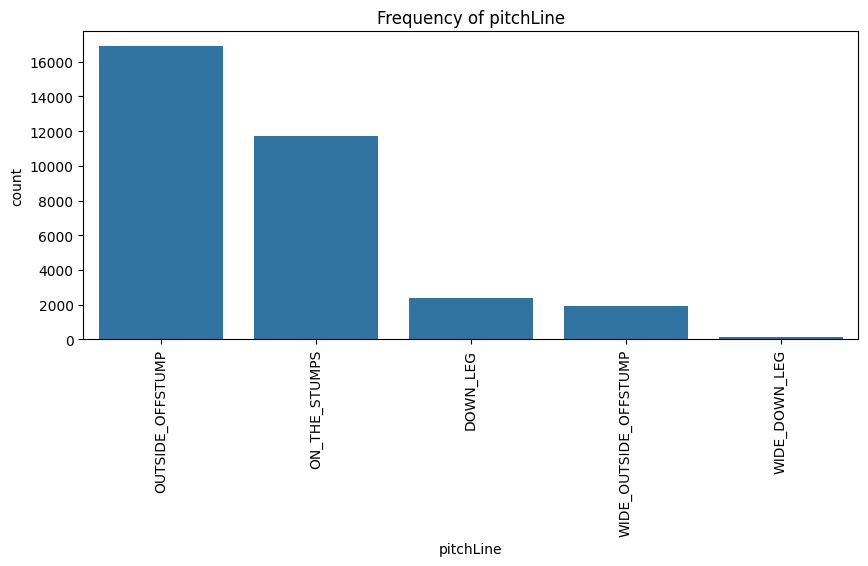

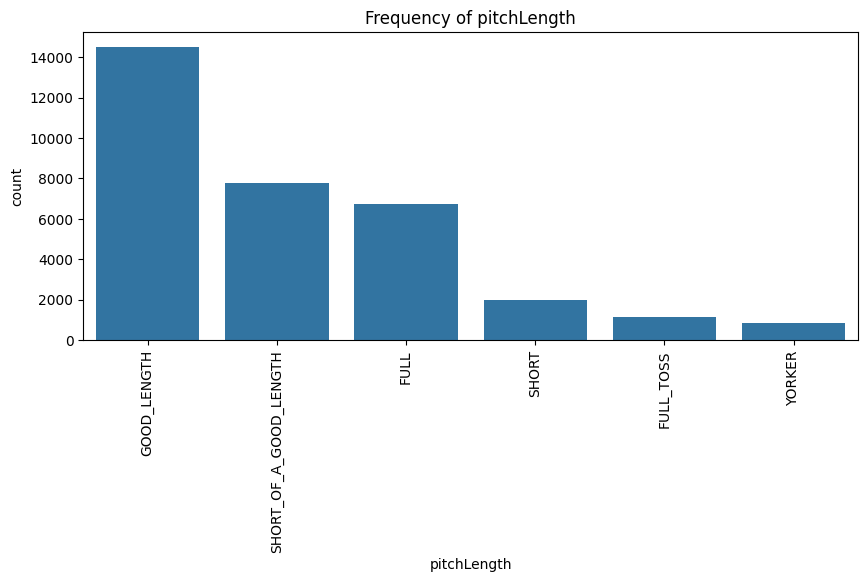

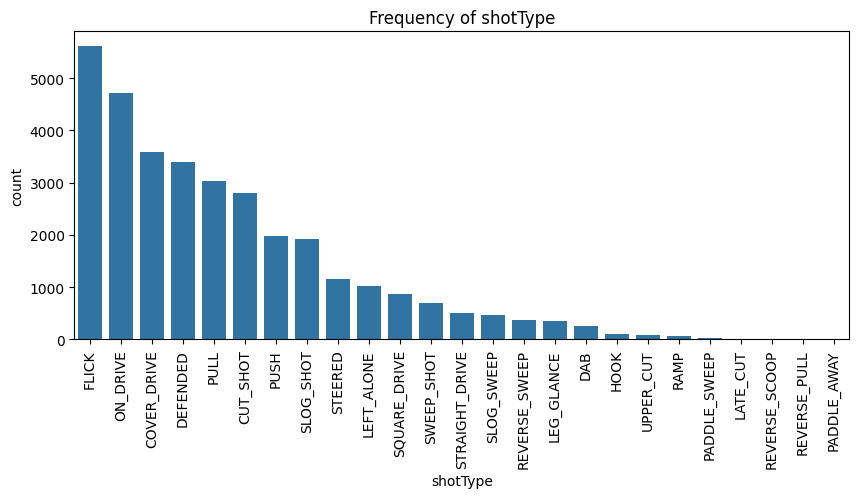

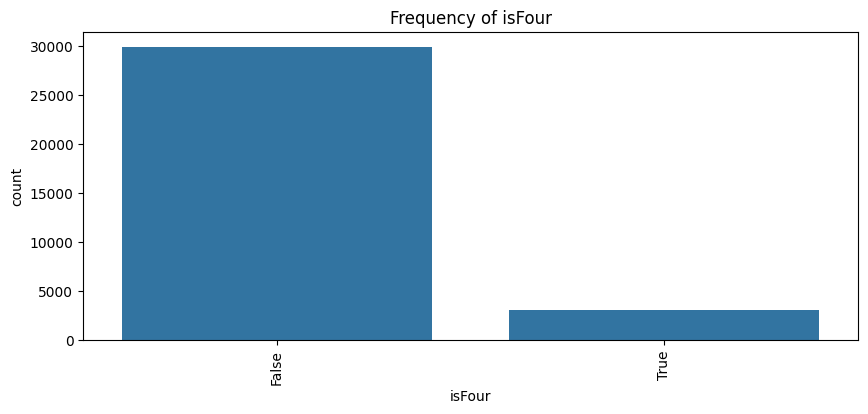

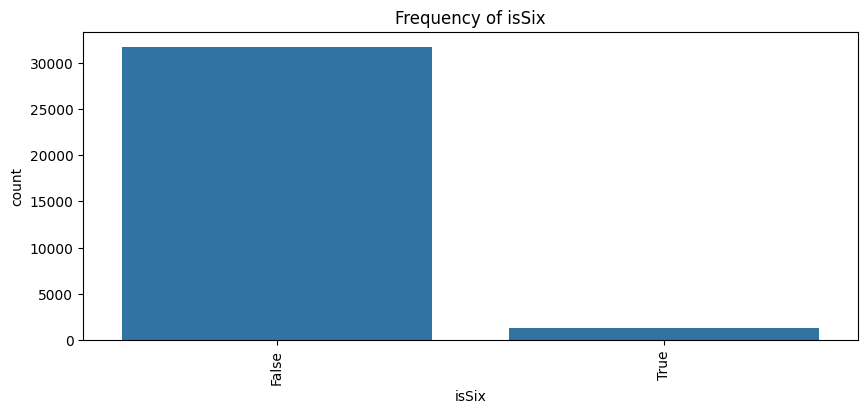

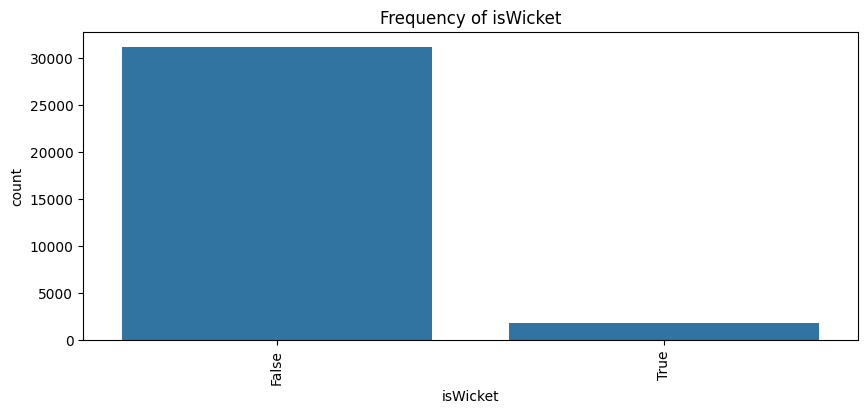

In [44]:
categorical_cols = ['pitchLine', 'pitchLength', 'shotType','isFour','isSix','isWicket']

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Frequency of {col}")
    plt.xticks(rotation=90)
    plt.show()

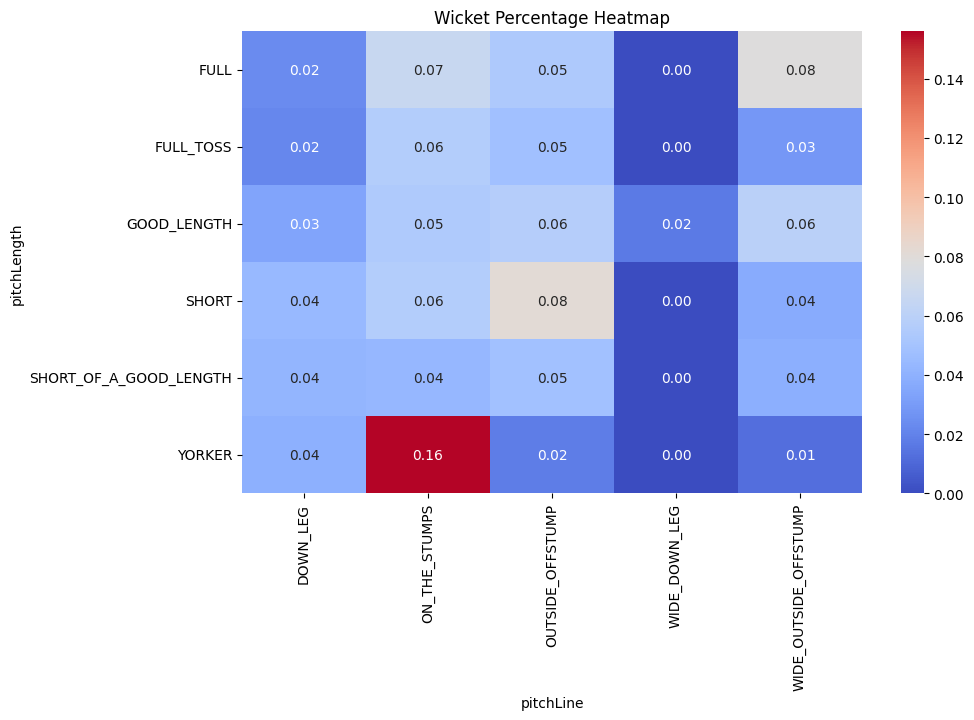

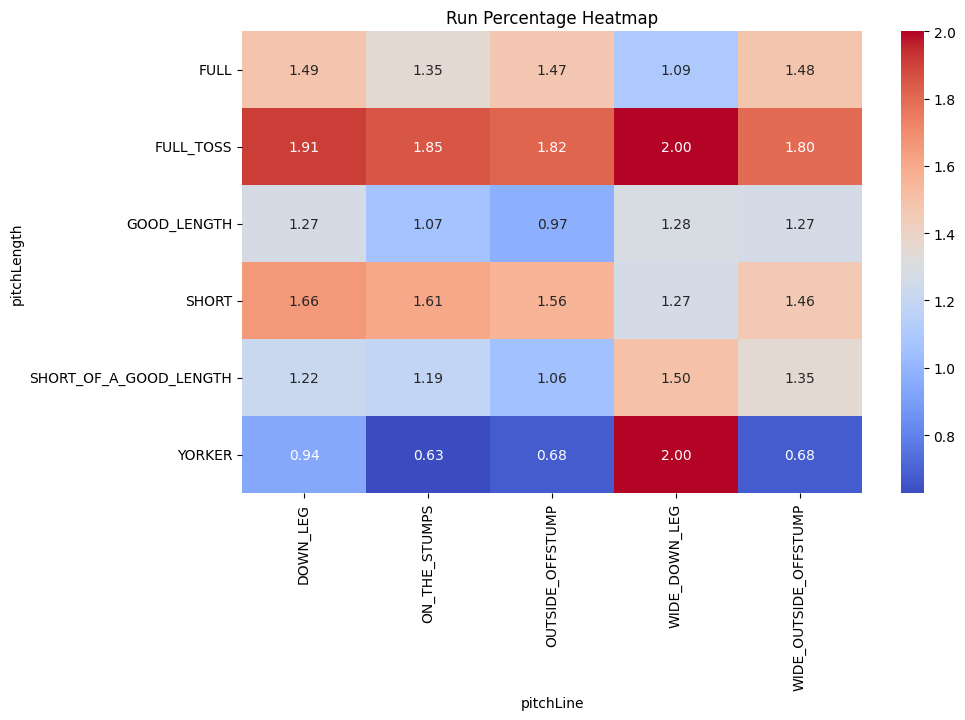

In [45]:
pivot_wicket = df.pivot_table(index='pitchLength', columns='pitchLine', values='isWicket', aggfunc='mean')
pivot_run = df.pivot_table(index='pitchLength', columns='pitchLine', values='run', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_wicket, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Wicket Percentage Heatmap')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_run, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Run Percentage Heatmap')
plt.show()

<Figure size 1200x600 with 0 Axes>

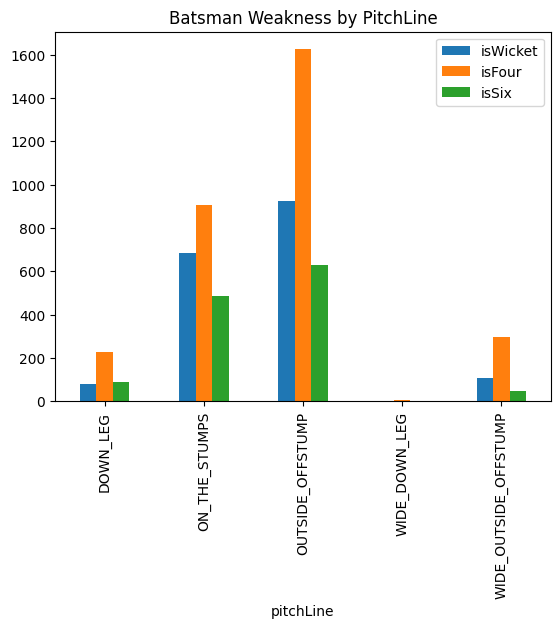

<Figure size 1200x600 with 0 Axes>

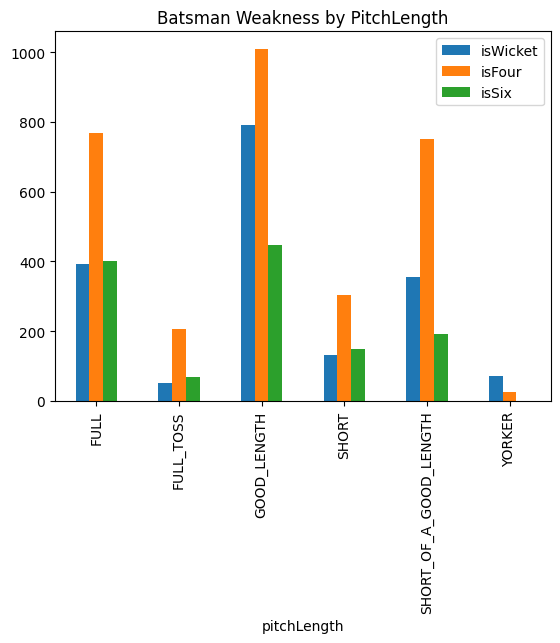

In [46]:
plt.figure(figsize=(12, 6))
df_grouped = df.groupby(['pitchLine'])[['isWicket', 'isFour', 'isSix']].sum().reset_index()
df_grouped.plot(x='pitchLine', kind='bar', stacked=False)
plt.title('Batsman Weakness by PitchLine')
plt.show()
plt.figure(figsize=(12, 6))
df_grouped = df.groupby(['pitchLength'])[['isWicket', 'isFour', 'isSix']].sum().reset_index()
df_grouped.plot(x='pitchLength', kind='bar', stacked=False)
plt.title('Batsman Weakness by PitchLength')
plt.show()

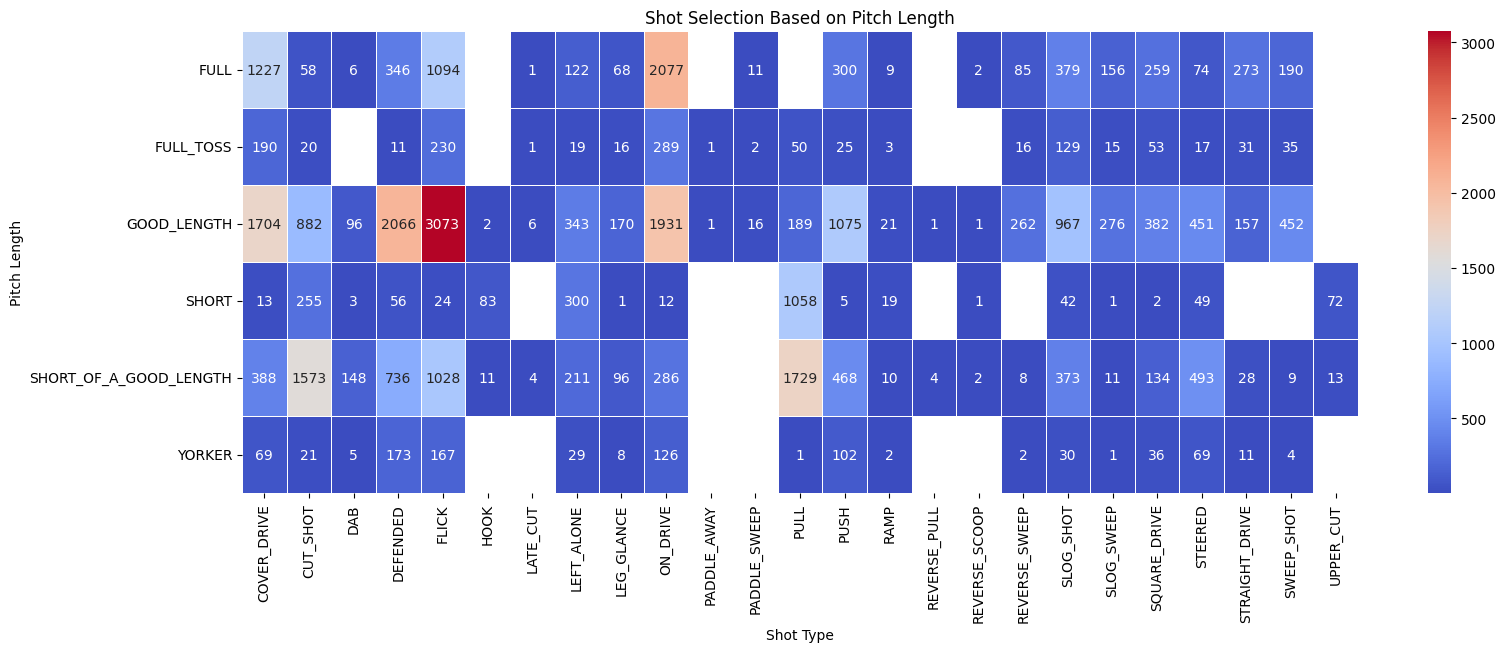

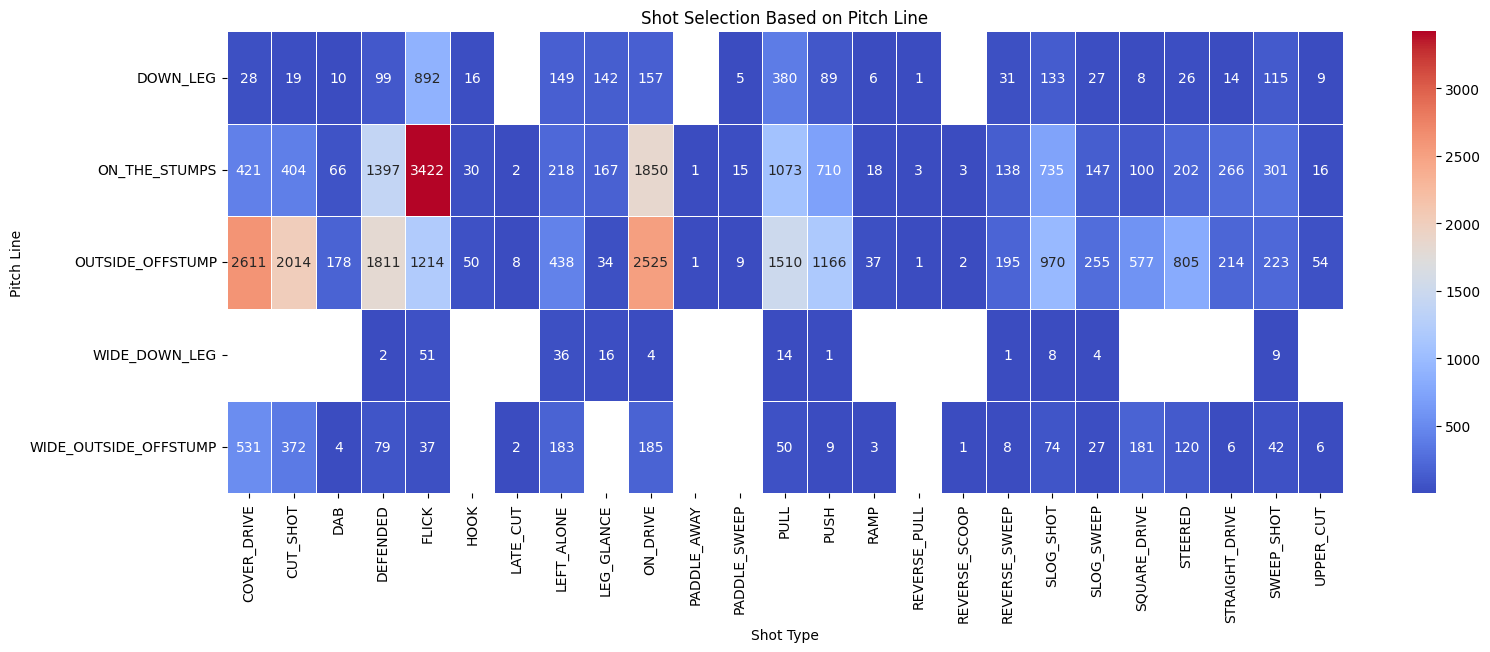

In [47]:
plt.figure(figsize=(18, 6))
pivot_shot_selection = df.pivot_table(index='pitchLength', columns='shotType', values='run', aggfunc='count')
sns.heatmap(pivot_shot_selection, cmap='coolwarm', annot=True, fmt=".0f", linewidths=0.5)
plt.title('Shot Selection Based on Pitch Length')
plt.xlabel('Shot Type')
plt.ylabel('Pitch Length')
plt.xticks(rotation=90)
plt.show()


plt.figure(figsize=(18, 6))
pivot_shot_selection = df.pivot_table(index='pitchLine', columns='shotType', values='run', aggfunc='count')
sns.heatmap(pivot_shot_selection, cmap='coolwarm', annot=True, fmt=".0f", linewidths=0.5)
plt.title('Shot Selection Based on Pitch Line')
plt.xlabel('Shot Type')
plt.ylabel('Pitch Line')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.to_csv('Preprocessed_Data.csv')

In [49]:
df.columns

Index(['match_obj_id', 'inningNumber', 'oversActual', 'pitchLine',
       'pitchLength', 'isFour', 'isSix', 'isWicket', 'byes', 'legbyes',
       'wides', 'noballs', 'run', 'totalRuns', 'totalWickets', 'shotType',
       'time_of_day', 'Ground Name', 'Batsman_Name', 'Batsman_Role',
       'Full Name', 'Batting Style (s)', 'Bowling Style (s)',
       'Batsman_Batting_Style', 'Batsman_Playing_Role', 'Bowler_Name',
       'Bowler_Role', 'Full Name_bowler', 'Batting Style (s)_bowler',
       'Bowling Style (s)_bowler', 'Bowler_Bowling_Style',
       'Bowler_Playing_Role'],
      dtype='object')